# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [98]:
# %% [markdown]
# # Deep Learning Assignment 1

# %%
%matplotlib inline
import os, itertools, random, copy, gc, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import torch.nn.functional as F
import scipy.stats as stats
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

notebook_dir = Path.cwd()
DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs" / "vanilla"
MODEL_SAVE_DIR = OUTPUTS_DIR / "models"

# ONLY DEFINED ONCE HERE!
RESULTS_PATH = OUTPUTS_DIR / "phase_a_grid_results.pkl" 

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Weights will be saved to: {MODEL_SAVE_DIR}")

Using device: cuda
Weights will be saved to: /home/raveco/deep_learning_ass1/outputs/vanilla/models


In [99]:
# %%
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(42)
g = torch.Generator()
g.manual_seed(42)

In [100]:
# %%
def get_train_val_test_data(validation_size=5000, train_transforms=transforms.ToTensor(), test_transforms=transforms.ToTensor()):
    full_train_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_transforms)
    full_val_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=test_transforms)
    test_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_transforms)

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size
    indices = torch.randperm(total_train_size).tolist()

    return (Subset(full_train_dataset, indices[:train_size]), 
            Subset(full_val_dataset, indices[train_size:]), 
            test_dataset)

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train images: 45000 | Val images: 5000 | Test images: 10000


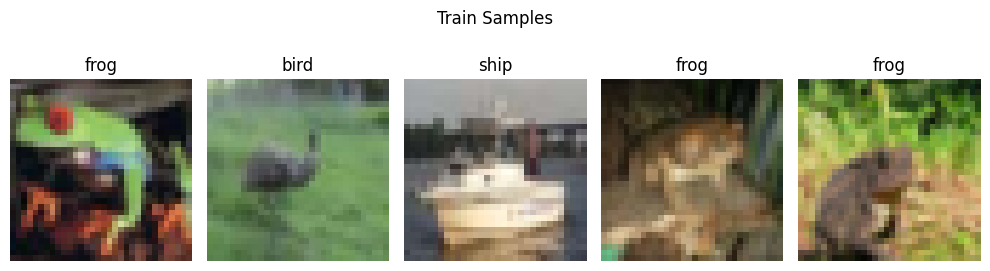

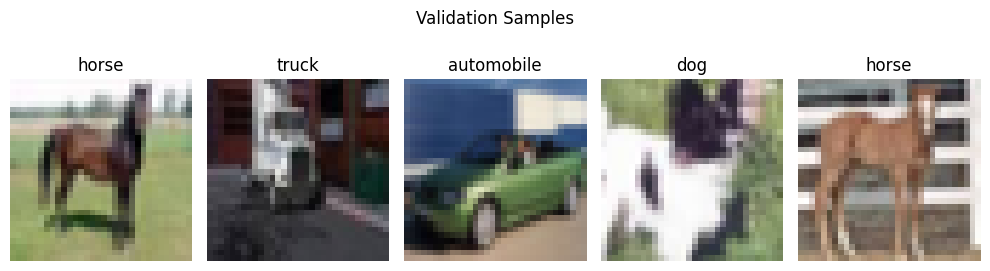

In [101]:
# %%
def save_figure(fig, filename):
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    return output_path

def show_images(dataset, num_images=5, title=""):
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes
    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()
        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")
    fig.tight_layout()
    return fig

fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png"); plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png"); plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32]) | Label: 6


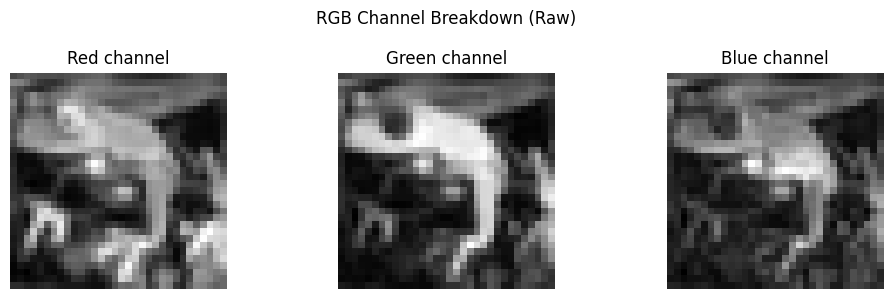

In [102]:
# %%
def debug_image_rgb(dataset):
    image, label = dataset[0] 
    print("Image shape (C, H, W):", image.shape, "| Label:", label)
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")
    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig

fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png"); plt.show()

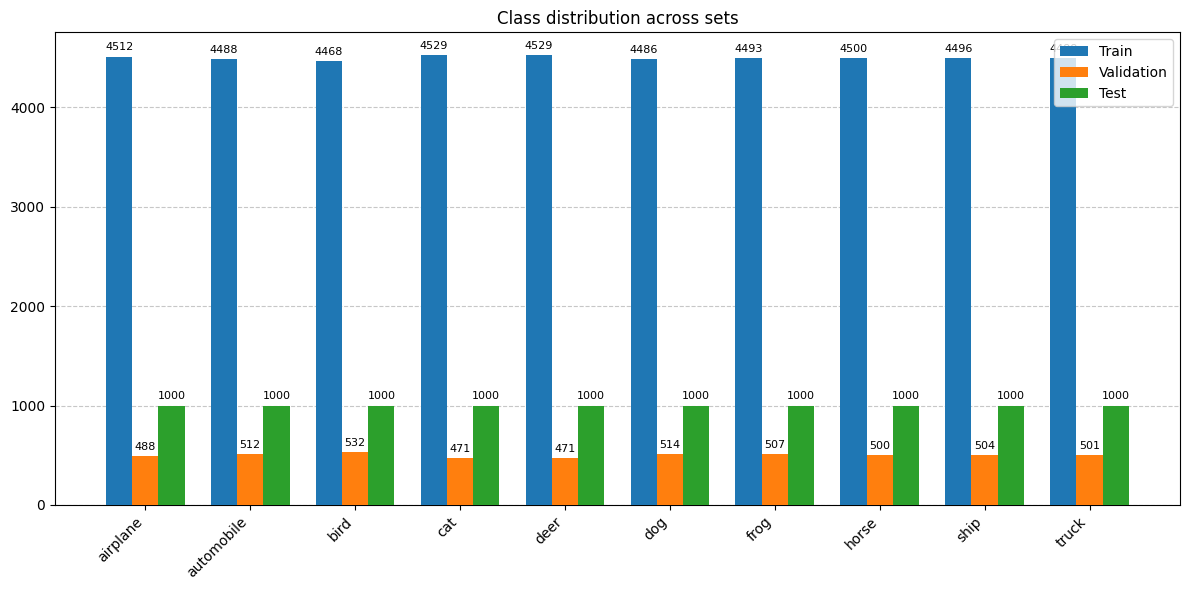

In [103]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    label_names = test_dataset.classes
    num_classes = len(label_names)
    train_counts, val_counts, test_counts = np.zeros(num_classes), np.zeros(num_classes), np.zeros(num_classes)

    for idx in train_dataset.indices: train_counts[train_dataset.dataset.targets[idx]] += 1
    for idx in val_dataset.indices: val_counts[val_dataset.dataset.targets[idx]] += 1
    for label in test_dataset.targets: test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Store the returned bars in variables and set zorder so they stay in front of grid lines
    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train", zorder=3)
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation", zorder=3)
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test", zorder=3)

    # 1. Print the result numbers above each bar
    # padding=3 adds a tiny gap between the bar and the text
    ax.bar_label(bars_train, padding=3, fmt='%d', fontsize=8)
    ax.bar_label(bars_val, padding=3, fmt='%d', fontsize=8)
    ax.bar_label(bars_test, padding=3, fmt='%d', fontsize=8)

    # 2. Add horizontal lines at every 1k values on the y-axis
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
    ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_title("Class distribution across sets")
    
    # Move legend slightly out of the way so it doesn't block the new text labels
    ax.legend(loc='upper right') 
    fig.tight_layout()
    return fig

fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

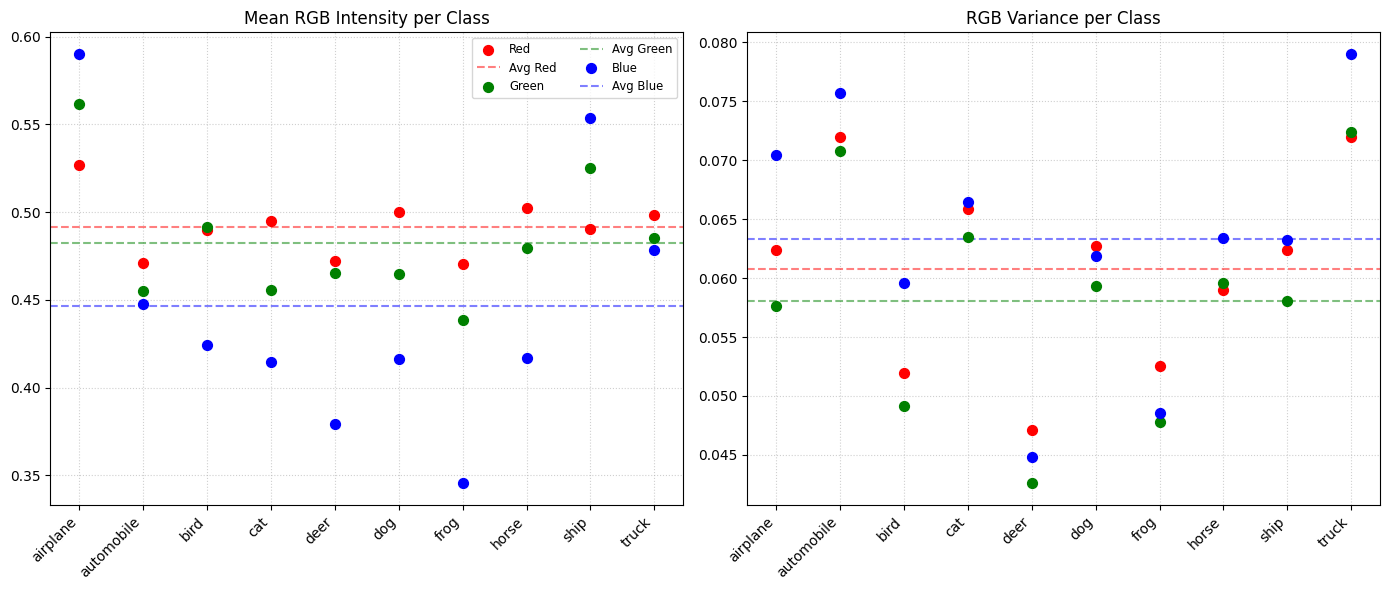

In [104]:
def compute_class_rgb_stats(dataset):
    num_classes = len(dataset.dataset.classes)
    pixel_sum, pixel_sq_sum, pixel_count = torch.zeros(num_classes, 3), torch.zeros(num_classes, 3), torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx] 
        img = img.view(3, -1) 
        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2
    return class_means.numpy(), class_vars.numpy()

def plot_rgb_stats(class_means, class_vars, class_names):
    x = np.arange(len(class_names))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = ['r', 'g', 'b']
    labels = ["Red", "Green", "Blue"]

    # Calculate global averages (mean of all classes) for the reference lines
    global_means = np.mean(class_means, axis=0)
    global_vars = np.mean(class_vars, axis=0)

    # 1. Mean RGB Intensity Plot
    for i in range(3):
        # Scatter plot for each class (NO connecting lines)
        axes[0].scatter(x, class_means[:, i], color=colors[i], marker='o', label=labels[i], s=50, zorder=3)
        # Horizontal dashed line for the global mean of that color
        axes[0].axhline(global_means[i], color=colors[i], linestyle='--', alpha=0.5, label=f'Avg {labels[i]}', zorder=2)

    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].grid(True, linestyle=':', alpha=0.6, zorder=0)
    axes[0].legend(loc='upper right', fontsize='small', ncol=2)

    # 2. RGB Variance Plot
    for i in range(3):
        # Scatter plot for each class (NO connecting lines)
        axes[1].scatter(x, class_vars[:, i], color=colors[i], marker='o', s=50, zorder=3)
        # Horizontal dashed line for the global average variance of that color
        axes[1].axhline(global_vars[i], color=colors[i], linestyle='--', alpha=0.5, zorder=2)

    axes[1].set_title("RGB Variance per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)

    fig.tight_layout()
    return fig

# Execute the updated logic
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)

# Save and show (updated filename)
save_figure(fig_rgb_stats, "rgb_stats_per_class_scatter.png")
plt.show()

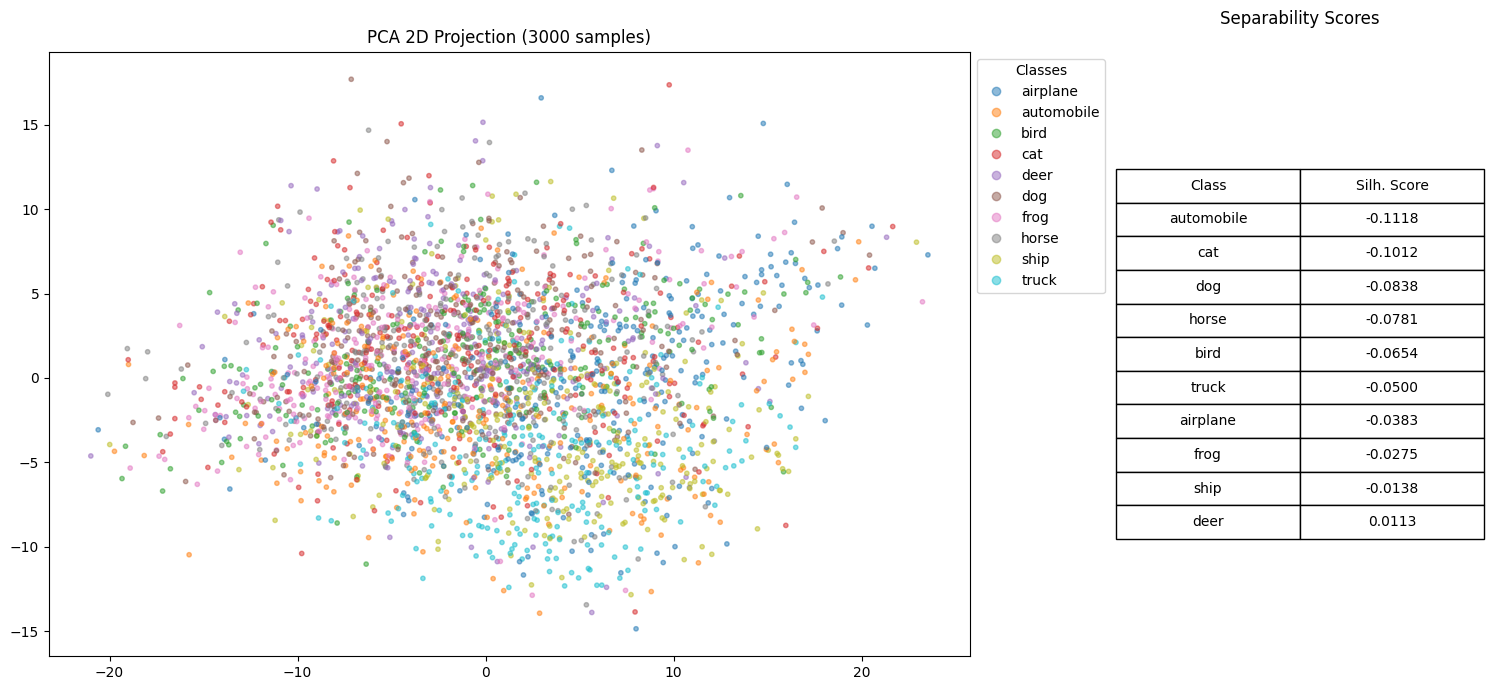

In [105]:
# %%
def plot_combined_analysis(dataset, num_samples=3000):
    images, labels = [], []
    for idx in dataset.indices[:num_samples]:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images, labels = np.array(images), np.array(labels)
    class_names = dataset.dataset.classes

    projected = PCA(n_components=2).fit_transform(images)
    sample_scores = silhouette_samples(images, labels)
    
    class_scores = [[class_names[i], f"{np.mean(sample_scores[labels == i]):.4f}"] for i in range(len(class_names))]
    class_scores.sort(key=lambda x: float(x[1]))

    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")

    ax_table.axis('off')
    table = ax_table.table(cellText=class_scores, colLabels=["Class", "Silh. Score"], loc='center', cellLoc='center')
    table.scale(1.2, 1.8); ax_table.set_title("Separability Scores", pad=20)
    fig.tight_layout()
    return fig

fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png"); plt.show()

In [106]:
# %%
def init_weights(model, init_type='kaiming'):
    def init_func(m):
        if isinstance(m, nn.Linear):
            if init_type == 'kaiming': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_type == 'xavier': nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
    model.apply(init_func)

def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device=device, scheduler=None, exp_name="Experiment", trial=None, l1_lambda=0.0, model_save_dir=None):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "stop_reason": "completed"}
    best_val_loss, best_val_acc, patience_counter = float('inf'), 0.0, 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

        if scheduler is not None: scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)

        if val_loader:
            model.eval()
            val_running_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for v_in, v_lab in val_loader:
                    v_in, v_lab = v_in.to(device), v_lab.to(device)
                    v_out = model(v_in)
                    val_running_loss += loss_fn(v_out, v_lab).item() * v_in.size(0)
                    _, v_pred = v_out.max(1)
                    total_val += v_lab.size(0)
                    correct_val += v_pred.eq(v_lab).sum().item()

            val_loss = val_running_loss / len(val_loader.dataset)
            val_acc = correct_val / total_val
            history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), MODEL_SAVE_DIR / f"{exp_name}_best.pth")

            if trial is not None:
                trial.report(val_acc, epoch)

            if trial is None:
                if epoch == 7 and val_acc < 0.35:
                    print(f"⚠️ [{exp_name}] Early stop: Poor performance at epoch 8")
                    history["stop_reason"] = "early_stop_bad_start"; break

                if val_loss < best_val_loss: best_val_loss = val_loss; patience_counter = 0 
                else: patience_counter += 1

                massive_overfit = (val_loss - train_loss) > 0.8 
                if patience_counter >= 5 or massive_overfit:
                    reason = "massive_divergence" if massive_overfit else "patience_exceeded"
                    print(f"🛑 [{exp_name}] Early Stopped ({reason}).")
                    history["stop_reason"] = f"early_stopped_overfit_{reason}"; break

    return history

def test(model, test_loader, loss_fn, device=device):
    model.to(device); model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += loss_fn(outputs, labels).item() * inputs.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    return test_loss / len(test_loader.dataset), correct / total

In [107]:
# %%
class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10, activation_name='relu'):
        super(VanillaMLP, self).__init__()
        acts = {'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 'gelu': nn.GELU(), 'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh()}
        activation = acts.get(activation_name.lower(), nn.ReLU())

        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(activation)
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

In [108]:
# %%
def plot_training_results(results_dict, exp_name=None):
    if exp_name is None: exp_name = list(results_dict.keys())[-1]
    data = results_dict[exp_name]
    history = data['history']
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Performance: {exp_name}', fontsize=16, fontweight='bold')

    # --- Loss Plot (ax1) ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 's-', label='Val Loss')
    ax1.set_title('Cross Entropy Loss VS Epochs')
    ax1.set_xlabel('Epochs', fontweight='bold') # Added X-axis title
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Accuracy Plot (ax2) ---
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 's-', label='Val Acc')
    ax2.set_title('Accuracy Score VS Epochs')
    ax2.set_xlabel('Epochs', fontweight='bold') # Added X-axis title
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    val_acc_val = float(history['val_acc'][-1]) if history['val_acc'] else 0.0
    fig.text(0.5, 0.02, f"Final Val Acc: {val_acc_val:.4f} | Stop Reason: {history['stop_reason']}", ha='center')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(OUTPUTS_DIR / f"{exp_name}_performance.png", dpi=300, bbox_inches='tight')
    plt.show()

In [109]:
# %%
print("🚀 Starting Phase A: Focused Grid Search...")

if RESULTS_PATH.exists():
    print(f"📂 Found existing results file. Resuming from {RESULTS_PATH}...")
    with open(RESULTS_PATH, "rb") as f: results_log = pickle.load(f)
else:
    results_log = {}

grid_params = {
    "hidden_dims": [[1024], [512, 256], [1024, 512, 128], [1024, 512, 256, 128]], 
    "activation": ["relu", "leaky_relu", "sigmoid"], 
    "lr": [1e-2, 1e-3, 5e-4, 1e-4, 1e-5],                          
    "scheduler": ["none", "cosine", "step"]                          
}

keys, values = zip(*grid_params.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

batch_size = 128; epochs = 50
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for i, config in enumerate(experiments):
    act, lr, sch = config['activation'], config['lr'], config['scheduler']
    exp_name = f"Exp_{i:03d}_L{len(config['hidden_dims'])}_W{config['hidden_dims'][0]}_{act}_lr{lr}_{sch}"
    
    if exp_name in results_log:
        print(f"⏩ Skipping {exp_name} (already completed).")
        continue

    print(f"\n🔹 Running {exp_name} ({i+1}/{len(experiments)})")
    model = VanillaMLP(hidden_dims=config["hidden_dims"], activation_name=act).to(device)
    init_weights(model, init_type='xavier' if act == "sigmoid" else 'kaiming')

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    config["optimizer"] = "adam"

    if sch == "step": scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    elif sch == "cosine": scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else: scheduler = None

    history = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs, device=device, scheduler=scheduler, exp_name=exp_name)
    results_log[exp_name] = {"config": config, "history": history}
    
    with open(RESULTS_PATH, "wb") as f: pickle.dump(results_log, f)

print(f"\n🎉 All Grid Search runs completed successfully!")

🚀 Starting Phase A: Focused Grid Search...
📂 Found existing results file. Resuming from /home/raveco/deep_learning_ass1/outputs/vanilla/phase_a_grid_results.pkl...
⏩ Skipping Exp_000_L1_W1024_relu_lr0.01_none (already completed).
⏩ Skipping Exp_001_L1_W1024_relu_lr0.01_cosine (already completed).
⏩ Skipping Exp_002_L1_W1024_relu_lr0.01_step (already completed).
⏩ Skipping Exp_003_L1_W1024_relu_lr0.001_none (already completed).
⏩ Skipping Exp_004_L1_W1024_relu_lr0.001_cosine (already completed).
⏩ Skipping Exp_005_L1_W1024_relu_lr0.001_step (already completed).
⏩ Skipping Exp_006_L1_W1024_relu_lr0.0005_none (already completed).
⏩ Skipping Exp_007_L1_W1024_relu_lr0.0005_cosine (already completed).
⏩ Skipping Exp_008_L1_W1024_relu_lr0.0005_step (already completed).
⏩ Skipping Exp_009_L1_W1024_relu_lr0.0001_none (already completed).
⏩ Skipping Exp_010_L1_W1024_relu_lr0.0001_cosine (already completed).
⏩ Skipping Exp_011_L1_W1024_relu_lr0.0001_step (already completed).
⏩ Skipping Exp_012_L1

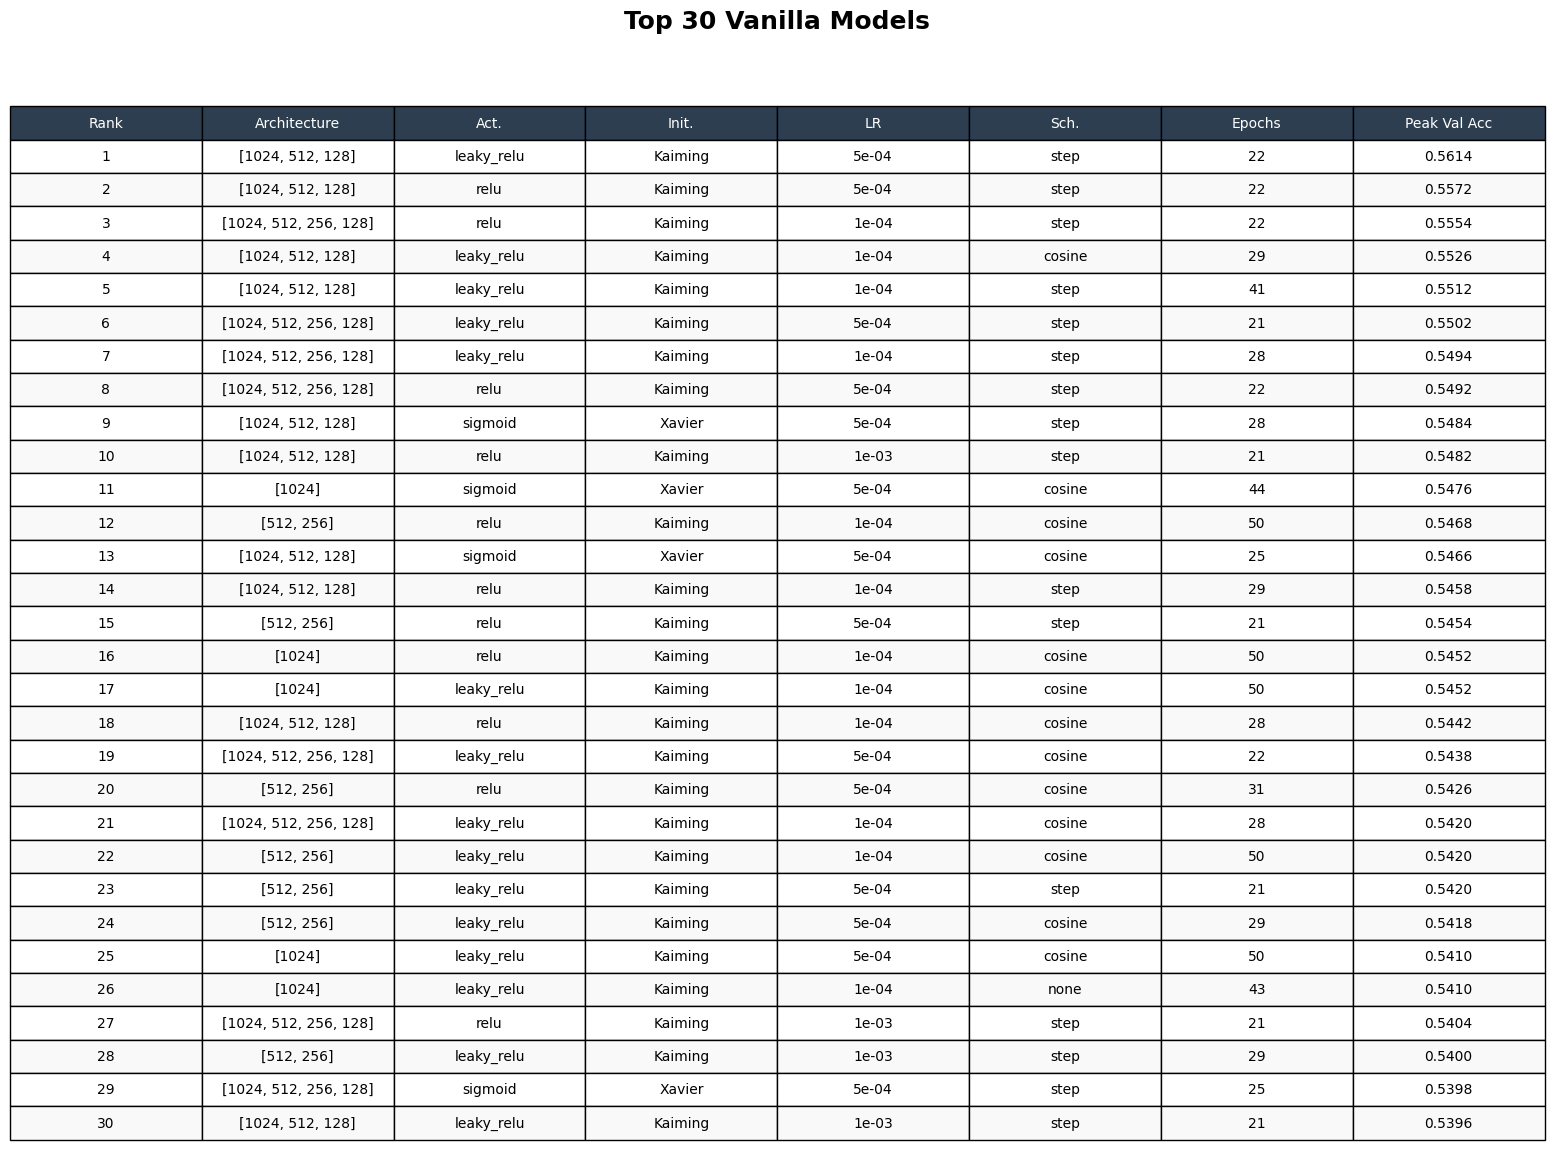

In [110]:
# %%
def analyze_top_results(results_path, top_n=30):
    if not results_path.exists(): return
    with open(results_path, "rb") as f: log = pickle.load(f)

    summary_data = []
    for name, data in log.items():
        c, h = data['config'], data['history']
        val_accs = h.get('val_acc', [])
        
        # Determine init based on the exact logic executed in the script
        act_name = c['activation'].lower()
        init_method = "Xavier" if act_name == "sigmoid" else "Kaiming"
        
        summary_data.append({
            "Architecture": str(c['hidden_dims']),
            "Act.": act_name,
            "Init.": init_method,
            "LR": f"{c['lr']:.0e}",
            "Sch.": c['scheduler'],
            "Epochs": len(val_accs),
            "Peak Val Acc": max(val_accs) if val_accs else 0
        })

    # Sort, take top N, and reset index
    df = pd.DataFrame(summary_data).sort_values(by="Peak Val Acc", ascending=False).head(top_n).reset_index(drop=True)
    
    # Insert Rank column at the very beginning
    df.insert(0, 'Rank', df.index + 1)
    
    # Format accuracy
    df['Peak Val Acc'] = df['Peak Val Acc'].map(lambda x: f"{x:.4f}")

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 14)); ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.scale(1.1, 2.0)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0: 
            cell.get_text().set_color('white')
            cell.set_facecolor('#2c3e50')
        elif row % 2 == 0: 
            cell.set_facecolor('#f9f9f9')

    plt.title(f"Top {top_n} Vanilla Models", fontsize=18, fontweight='bold', pad=40)
    plt.savefig(OUTPUTS_DIR / "top_30_vanilla.png", dpi=300, bbox_inches='tight')
    plt.show()

analyze_top_results(RESULTS_PATH)

🏆 Best Model Found: Exp_113_L3_W1024_leaky_relu_lr0.0005_step
⭐ Peak Validation Accuracy: 0.5614


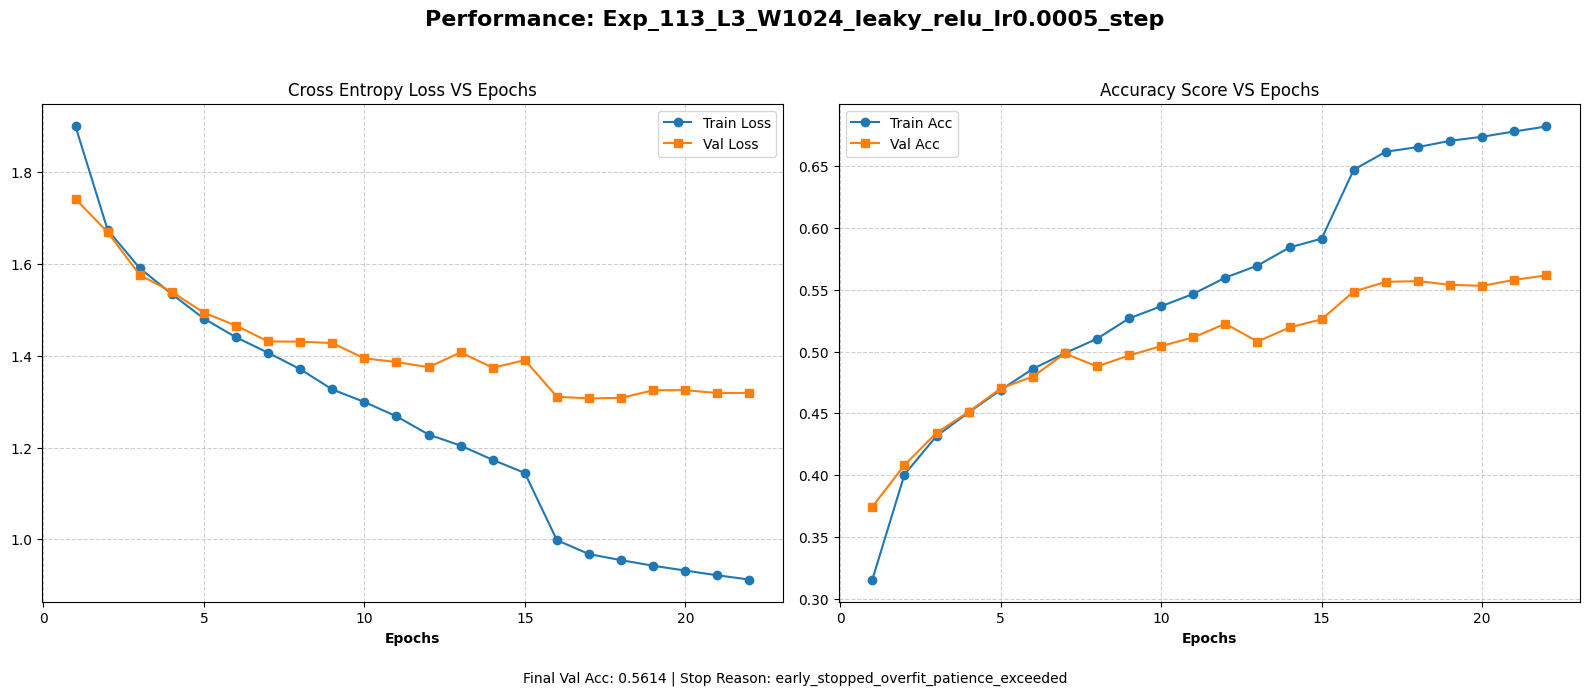

In [111]:
# %% [markdown]
# ## Plot Best Ranked Vanilla Model
# Automatically finds the top-performing model from Phase A and visualizes its training curves.

# %%
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "rb") as f:
        results_log = pickle.load(f)

    # Find the experiment with the maximum peak validation accuracy
    best_exp_name = None
    best_val_acc = -1

    for exp_name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [0])
        peak_acc = max(val_accs) if val_accs else 0
        
        if peak_acc > best_val_acc:
            best_val_acc = peak_acc
            best_exp_name = exp_name

    print(f"🏆 Best Model Found: {best_exp_name}")
    print(f"⭐ Peak Validation Accuracy: {best_val_acc:.4f}")

    # Plot using your existing function from Cell 11
    plot_training_results(results_log, exp_name=best_exp_name)
else:
    print(f"❌ Results file not found at {RESULTS_PATH}")

In [112]:
# %% [markdown]
# ## Phase A: Final Test Set Evaluation
# Evaluating the Chosen VanillaMLP on the unseen test dataset.

# %%
if 'best_exp_name' in locals() and best_exp_name:
    print(f"Loading best baseline model: {best_exp_name}")
    
    # --- FIX: Initialize the test_loader ---
    # We use a batch size of 128 (same as training) and shuffle=False for testing
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    # 1. Reconstruct the best configuration from the log
    best_config = results_log[best_exp_name]['config']
    
    # 2. Initialize the model with these exact parameters
    chosen_vanilla_model = VanillaMLP(
        hidden_dims=best_config['hidden_dims'], 
        activation_name=best_config['activation']
    ).to(device)
    
    # 3. Load the saved best weights
    weights_path = MODEL_SAVE_DIR / f"{best_exp_name}_best.pth"
    chosen_vanilla_model.load_state_dict(torch.load(weights_path, map_location=device))
    
    # 4. Evaluate on the test set using your existing test() function
    test_loss, test_acc = test(chosen_vanilla_model, test_loader, loss_fn, device=device)
    
    print("\n" + "="*50)
    print("🏆 Final Vanilla MLP Test Set Metrics")
    print("="*50)
    print(f"i.  Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
    print(f"ii. Loss:     {test_loss:.4f}")
    print("="*50)
else:
    print("❌ Could not find 'best_exp_name'. Please run the previous cell first.")

Loading best baseline model: Exp_113_L3_W1024_leaky_relu_lr0.0005_step

🏆 Final Vanilla MLP Test Set Metrics
i.  Accuracy: 0.5497 (54.97%)
ii. Loss:     1.3084


Phase B


In [113]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[1024, 512, 128], num_classes=10, 
                 activation_name='leaky_relu', use_batchnorm=False, dropout_rate=0.0):
        super(ImprovedMLP, self).__init__()
        
        acts = {'relu': nn.ReLU(), 'leaky_relu': nn.LeakyReLU(0.01), 'gelu': nn.GELU()}
        activation = acts.get(activation_name.lower(), nn.ReLU())

        layers = []
        prev_dim = input_size
        
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dim))
            layers.append(activation)
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) 
        return self.model(x)


In [114]:
# %%
# Phase B paths (separate from vanilla Phase A)
IMPROVED_OUTPUTS_DIR = notebook_dir / "outputs" / "improved"
IMPROVED_MODEL_SAVE_DIR = IMPROVED_OUTPUTS_DIR / "models"
IMPROVED_RESULTS_PATH = IMPROVED_OUTPUTS_DIR / "phase_b_results.pkl"

IMPROVED_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2023, 0.1994, 0.2010]

# Reuse Part 1 split indices (same train/val images for every Phase B run)
PHASE_B_TRAIN_INDICES = list(train_dataset.indices)
PHASE_B_VAL_INDICES = list(val_dataset.indices)

_dataset_cache = {}

def _build_transforms(config):
    train_transforms_list, test_transforms_list = [], [transforms.ToTensor()]
    if config['augmentation'] in ['crop', 'both']:
        train_transforms_list.append(transforms.RandomCrop(32, padding=4))
    if config['augmentation'] in ['rotate', 'both']:
        train_transforms_list.append(transforms.RandomRotation(15))
    train_transforms_list.append(transforms.ToTensor())
    if config['input_norm']:
        norm_layer = transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
        train_transforms_list.append(norm_layer)
        test_transforms_list.append(norm_layer)
    return transforms.Compose(train_transforms_list), transforms.Compose(test_transforms_list)

def get_dataloaders(config, batch_size=128):
    train_transform, test_transform = _build_transforms(config)
    cache_key = (repr(train_transform), repr(test_transform))
    if cache_key not in _dataset_cache:
        full_train = datasets.CIFAR10(root=str(DATA_ROOT), train=True, transform=train_transform, download=True)
        full_val = datasets.CIFAR10(root=str(DATA_ROOT), train=True, transform=test_transform, download=True)
        _dataset_cache[cache_key] = (
            Subset(full_train, PHASE_B_TRAIN_INDICES),
            Subset(full_val, PHASE_B_VAL_INDICES),
        )
    train_ds, val_ds = _dataset_cache[cache_key]
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

def get_phase_b_rank_list(results_log):
    rank_list = []
    for name, data in results_log.items():
        val_accs = data['history'].get('val_acc', [])
        peak_acc = max(val_accs) if val_accs else 0
        rank_list.append((name, peak_acc, data['config']))
    rank_list.sort(key=lambda x: x[1], reverse=True)
    return rank_list

phase_b_experiments = [
    {"name": "B_00_Baseline", "input_norm": False, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_01_InputNorm", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_02_Aug_Crop", "input_norm": True, "augmentation": "crop", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_03_Aug_Rotate", "input_norm": True, "augmentation": "rotate", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_04_BatchNorm", "input_norm": True, "augmentation": "none", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_05_L2_Reg", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 1e-4, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_06_L1_Reg", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 1e-5, "dropout": 0.0},
    {"name": "B_07_Dropout_0.1", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_08_Dropout_0.2", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.2},
    {"name": "B_09_Dropout_0.3", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_10_Dropout_0.4", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.4},
    {"name": "B_11_Dropout_0.5", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.5},
    {"name": "B_12_Combo_Aug_Both", "input_norm": True, "augmentation": "both", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_13_Combo_BN_Drop", "input_norm": True, "augmentation": "none", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_14_Combo_BN_L2", "input_norm": True, "augmentation": "none", "batchnorm": True, "l2_wd": 1e-4, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_15_Combo_Drop_L2", "input_norm": True, "augmentation": "none", "batchnorm": False, "l2_wd": 1e-4, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_16_Combo_AugCrop_Drop", "input_norm": True, "augmentation": "crop", "batchnorm": False, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_17_Combo_BN_AugCrop", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_18_Combo_BN_Drop_L2", "input_norm": True, "augmentation": "none", "batchnorm": True, "l2_wd": 1e-4, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_19_Combo_BN_AugBoth_Drop", "input_norm": True, "augmentation": "both", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_20_Ultimate_Combo", "input_norm": True, "augmentation": "both", "batchnorm": True, "l2_wd": 1e-4, "l1_lambda": 0.0, "dropout": 0.3},
    {"name": "B_21_Rank1_Drop_0.05", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.05},
    {"name": "B_22_Rank1_Drop_0.1", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_23_Rank1_Drop_0.15", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.15},
    {"name": "B_24_Rank1_L2_1e-5", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-5, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_25_Rank1_L2_1e-6", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-6, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_26_Rank1_LR_1e-3", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0, "custom_lr": 1e-3},
    {"name": "B_27_Rank1_LR_3e-4", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0, "custom_lr": 3e-4},
    {"name": "B_28_Rank1_Light_Combo", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-6, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_29_Rank1_BothAug", "input_norm": True, "augmentation": "both", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 0.0, "dropout": 0.0},
    {"name": "B_30_L2_1e-8", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-8, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_31_L2_1e-7", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-7, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_32_L2_1e-6", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-6, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_33_L2_1e-5", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-5, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_34_L2_5e-5", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 5e-5, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_35_L2_1e-3", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 1e-3, "l1_lambda": 0.0, "dropout": 0.1},
    {"name": "B_36_L1_1e-8", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 1e-8, "dropout": 0.1},
    {"name": "B_37_L1_1e-7", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 1e-7, "dropout": 0.1},
    {"name": "B_38_L1_1e-6", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 1e-6, "dropout": 0.1},
    {"name": "B_39_L1_5e-6", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 5e-6, "dropout": 0.1},
    {"name": "B_40_L1_1e-5", "input_norm": True, "augmentation": "crop", "batchnorm": True, "l2_wd": 0.0, "l1_lambda": 1e-5, "dropout": 0.1},
]

if IMPROVED_RESULTS_PATH.exists():
    print(f"📂 Found existing Phase B results. Resuming from {IMPROVED_RESULTS_PATH}...")
    with open(IMPROVED_RESULTS_PATH, "rb") as f:
        phase_b_results_log = pickle.load(f)
else:
    phase_b_results_log = {}

loss_fn = nn.CrossEntropyLoss()
batch_size = 128

for i, config in enumerate(phase_b_experiments):
    exp_name = config["name"]
    if exp_name in phase_b_results_log:
        print(f"⏩ Skipping {exp_name} (already completed).")
        continue

    print(f"\n" + "="*60)
    print(f"🔹 Running {exp_name} ({i+1}/{len(phase_b_experiments)})")
    print(f"🔹 Config: {config}")
    print("="*60)

    train_loader, val_loader = get_dataloaders(config, batch_size=batch_size)
    model = ImprovedMLP(
        hidden_dims=[1024, 512, 128],
        activation_name='leaky_relu',
        use_batchnorm=config['batchnorm'],
        dropout_rate=config['dropout']
    ).to(device)
    init_weights(model)

    current_lr = config.get('custom_lr', 5e-4)
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr, weight_decay=config['l2_wd'])

    history = train(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=50,
        device=device,
        exp_name=exp_name,
        l1_lambda=config['l1_lambda'],
        model_save_dir=IMPROVED_MODEL_SAVE_DIR,
    )

    phase_b_results_log[exp_name] = {"config": config, "history": history}
    plot_training_results(phase_b_results_log, exp_name=exp_name, outputs_dir=IMPROVED_OUTPUTS_DIR)

    with open(IMPROVED_RESULTS_PATH, "wb") as f:
        pickle.dump(phase_b_results_log, f)

print(f"\n🎉 Phase B study completed. Results: {IMPROVED_RESULTS_PATH}")

📂 Found existing Phase B results. Resuming from /home/raveco/deep_learning_ass1/outputs/improved/phase_b_results.pkl...
⏩ Skipping B_00_Baseline (already completed).
⏩ Skipping B_01_InputNorm (already completed).
⏩ Skipping B_02_Aug_Crop (already completed).
⏩ Skipping B_03_Aug_Rotate (already completed).
⏩ Skipping B_04_BatchNorm (already completed).
⏩ Skipping B_05_L2_Reg (already completed).
⏩ Skipping B_06_L1_Reg (already completed).
⏩ Skipping B_07_Dropout_0.1 (already completed).
⏩ Skipping B_08_Dropout_0.2 (already completed).
⏩ Skipping B_09_Dropout_0.3 (already completed).
⏩ Skipping B_10_Dropout_0.4 (already completed).
⏩ Skipping B_11_Dropout_0.5 (already completed).
⏩ Skipping B_12_Combo_Aug_Both (already completed).
⏩ Skipping B_13_Combo_BN_Drop (already completed).
⏩ Skipping B_14_Combo_BN_L2 (already completed).
⏩ Skipping B_15_Combo_Drop_L2 (already completed).
⏩ Skipping B_16_Combo_AugCrop_Drop (already completed).
⏩ Skipping B_17_Combo_BN_AugCrop (already completed).


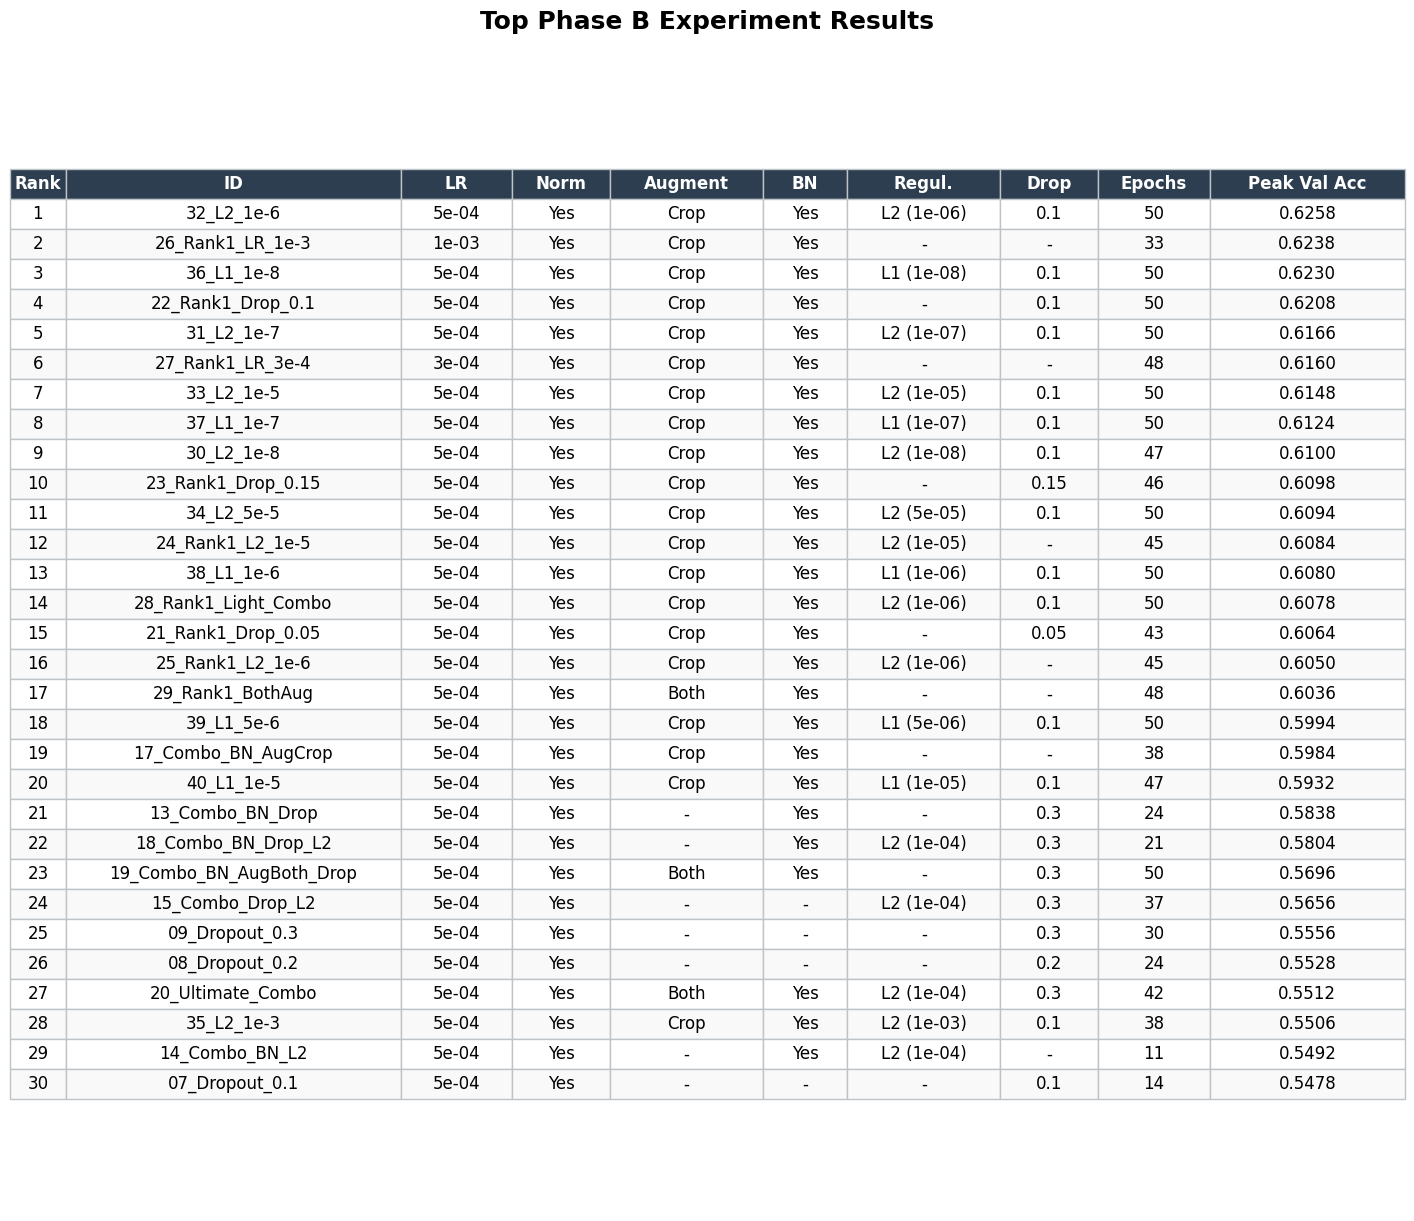

In [128]:
def analyze_phase_b_results(top_n=20, results_path=IMPROVED_RESULTS_PATH):
    if not results_path.exists():
        print(f"❌ Could not find {results_path}")
        return

    with open(results_path, "rb") as f:
        log = pickle.load(f)

    summary_data = []
    for name, data in log.items():
        c, h = data['config'], data['history']
        val_accs = h.get('val_acc', [])
        epochs_run = len(val_accs)
        regul_val = "-"
        if c.get('l2_wd', 0) > 0:
            regul_val = f"L2 ({c['l2_wd']:.0e})"
        elif c.get('l1_lambda', 0) > 0:
            regul_val = f"L1 ({c['l1_lambda']:.0e})"
        summary_data.append({
            "ID": name.split('_', 1)[-1] if '_' in name else name,
            "LR": f"{c.get('custom_lr', 5e-4):.0e}",
            "Norm": "Yes" if c['input_norm'] else "-",
            "Augment": c['augmentation'].title() if c['augmentation'] != "none" else "-",
            "BN": "Yes" if c['batchnorm'] else "-",
            "Regul.": regul_val,
            "Drop": str(c['dropout']) if c['dropout'] > 0 else "-",
            "Epochs": epochs_run,
            "Peak Val Acc": max(val_accs) if val_accs else 0,
        })

    df = pd.DataFrame(summary_data).sort_values(by="Peak Val Acc", ascending=False).head(top_n).reset_index(drop=True)
    df.insert(0, 'Rank', df.index + 1)
    df['Peak Val Acc'] = df['Peak Val Acc'].map(lambda x: f"{x:.4f}")

    fig_height = max(8, len(df) * 0.5)
    fig, ax = plt.subplots(figsize=(15, fig_height))
    ax.axis('off')
    
    # Updated column widths for 10 columns (added Epochs)
    custom_widths = [0.04, 0.24, 0.08, 0.07, 0.11, 0.06, 0.11, 0.07, 0.08, 0.14]

    table = ax.table(
        cellText=df.values, 
        colLabels=df.columns, 
        cellLoc='center', 
        loc='center',
        colWidths=custom_widths 
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#bdc3c7')
        if row == 0:
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
            cell.set_facecolor('#2c3e50')
        elif row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
            
    plt.title("Top Phase B Experiment Results", fontsize=18, fontweight='bold', pad=20)
    plt.savefig(IMPROVED_OUTPUTS_DIR / "phase_b_top_results.png", dpi=300, bbox_inches='tight')
    plt.show()

analyze_phase_b_results(top_n=30)

🥇 RANK 1: B_32_L2_1e-6
⭐ Peak Val Acc:   0.6258
📈 Peak Train Acc: 0.6112
📉 Min Val Loss:   1.0654


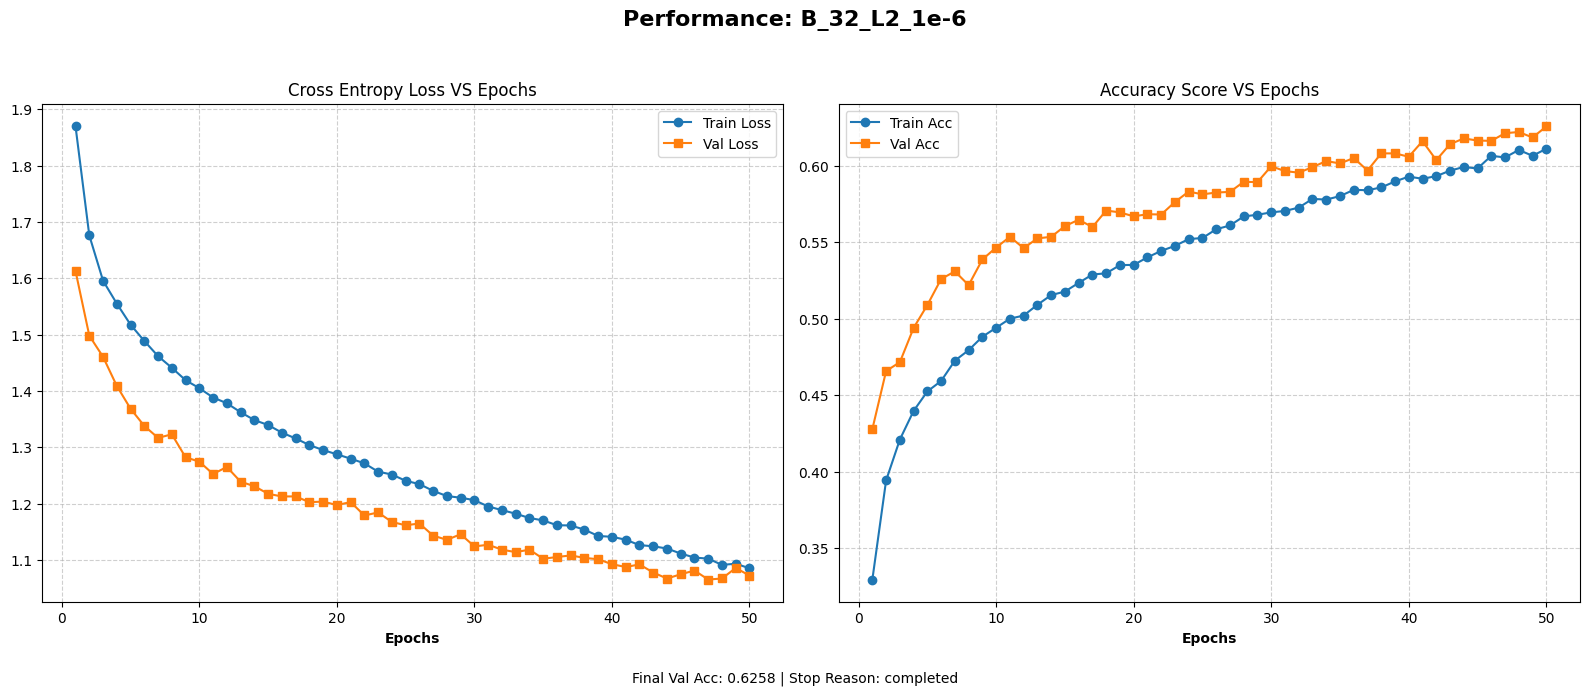

In [116]:
# %% [markdown]
# ## Plot Rank 1 Improved Model

# %%
if IMPROVED_RESULTS_PATH.exists():
    with open(IMPROVED_RESULTS_PATH, "rb") as f:
        phase_b_results_log = pickle.load(f)
    rank_list = get_phase_b_rank_list(phase_b_results_log)
    if rank_list:
        name, peak_val, _ = rank_list[0]
        hist = phase_b_results_log[name]['history']
        print(f"🥇 RANK 1: {name}")
        print(f"⭐ Peak Val Acc:   {peak_val:.4f}")
        print(f"📈 Peak Train Acc: {max(hist.get('train_acc', [0])):.4f}")
        print(f"📉 Min Val Loss:   {min(hist.get('val_loss', [float('inf')])):.4f}")
        plot_training_results(phase_b_results_log, exp_name=name)
    else:
        print("❌ No experiments in Phase B results.")
else:
    print(f"❌ Results file not found: {IMPROVED_RESULTS_PATH}")


In [117]:
# %% [markdown]
# ## Evaluate Rank 1 Improved Model on Test Set

# %%
if not IMPROVED_RESULTS_PATH.exists():
    print(f"❌ Results file not found: {IMPROVED_RESULTS_PATH}")
else:
    with open(IMPROVED_RESULTS_PATH, "rb") as f:
        phase_b_results_log = pickle.load(f)

    # 1. Use the bulletproof logic to find the true Rank 1 model
    def get_peak_val_acc(exp_data):
        history = exp_data.get('history', {})
        val_accs = history.get('val_acc', [])
        valid_accs = [acc for acc in val_accs if isinstance(acc, (int, float))]
        return max(valid_accs) if valid_accs else 0

    sorted_exps = sorted(
        phase_b_results_log.items(), 
        key=lambda x: get_peak_val_acc(x[1]), 
        reverse=True
    )
    
    if not sorted_exps:
        print("❌ No models found in Phase B results log.")
    else:
        rank_1_name, rank_1_data = sorted_exps[0]
        rank_1_config = rank_1_data.get('config', {})
        
        # --- EXTRACT ALL STATS ---
        history = rank_1_data.get('history', {})
        v_accs = [x for x in history.get('val_acc', []) if isinstance(x, (int, float))]
        t_accs = [x for x in history.get('train_acc', []) if isinstance(x, (int, float))]
        v_loss = [x for x in history.get('val_loss', []) if isinstance(x, (int, float))]
        t_loss = [x for x in history.get('train_loss', []) if isinstance(x, (int, float))]
        
        peak_val = max(v_accs) if v_accs else 0
        peak_train = max(t_accs) if t_accs else 0
        min_v_loss = min(v_loss) if v_loss else float('inf')
        min_t_loss = min(t_loss) if t_loss else float('inf')
        
        print(f"🥇 Evaluating Rank 1: {rank_1_name}")
        print("-" * 35)
        print("📊 TRAINING STATISTICS:")
        print(f"   ⭐ Peak Val Acc:    {peak_val:.4f}")
        print(f"   📈 Peak Train Acc:  {peak_train:.4f}")
        print(f"   📉 Min Val Loss:    {min_v_loss:.4f}")
        print(f"   📉 Min Train Loss:  {min_t_loss:.4f}")
        
        # Print the hyperparameters used
        reg_type = "L2" if rank_1_config.get('l2_wd', 0) > 0 else ("L1" if rank_1_config.get('l1_lambda', 0) > 0 else "None")
        print("\n⚙️ MODEL CONFIGURATION:")
        print(f"   Regularization: {reg_type}")
        print(f"   Dropout Rate:   {rank_1_config.get('dropout', 'N/A')}")
        print(f"   Augmentation:   {rank_1_config.get('augmentation', 'N/A')}")
        print(f"   BatchNorm:      {rank_1_config.get('batchnorm', 'N/A')}")
        print("-" * 35)

        # 2. Build test transforms based on the config
        _, test_transform = _build_transforms(rank_1_config)
        test_ds = datasets.CIFAR10(root=str(DATA_ROOT), train=False, transform=test_transform, download=True)
        test_loader_b = DataLoader(test_ds, batch_size=128, shuffle=False)

        # 3. Initialize Model (using your optimal Phase A dimensions & activation)
        model = ImprovedMLP(
            hidden_dims=[1024, 512, 128],
            activation_name='leaky_relu',
            use_batchnorm=rank_1_config.get('batchnorm', True),
            dropout_rate=rank_1_config.get('dropout', 0.1),
        ).to(device)

        # 4. Find the correct weights file (checking both naming formats)
        weights_path_1 = IMPROVED_MODEL_SAVE_DIR / f"{rank_1_name}.pth"
        weights_path_2 = IMPROVED_MODEL_SAVE_DIR / f"{rank_1_name}_best.pth"
        
        if weights_path_1.exists():
            actual_weights_path = weights_path_1
        elif weights_path_2.exists():
            actual_weights_path = weights_path_2
        else:
            actual_weights_path = None

        if actual_weights_path:
            model.load_state_dict(torch.load(actual_weights_path, map_location=device))
            
            # 5. Evaluate on the test set
            test_loss, test_acc = test(model, test_loader_b, loss_fn, device=device)
            
            print(f"\n✅ FINAL TEST RESULT for {rank_1_name}:")
            print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
            print(f"   Test Loss:     {test_loss:.4f}")
            print("-" * 35)
        else:
            print(f"❌ Weights file not found. Looked for:")
            print(f"   - {weights_path_1}")
            print(f"   - {weights_path_2}")

🥇 Evaluating Rank 1: B_32_L2_1e-6
-----------------------------------
📊 TRAINING STATISTICS:
   ⭐ Peak Val Acc:    0.6258
   📈 Peak Train Acc:  0.6112
   📉 Min Val Loss:    1.0654
   📉 Min Train Loss:  1.0854

⚙️ MODEL CONFIGURATION:
   Regularization: L2
   Dropout Rate:   0.1
   Augmentation:   crop
   BatchNorm:      True
-----------------------------------


/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



✅ FINAL TEST RESULT for B_32_L2_1e-6:
   Test Accuracy: 0.6088 (60.88%)
   Test Loss:     1.1044
-----------------------------------


Question 3

In [118]:
model = ImprovedMLP(
    hidden_dims=[1024, 512, 128],
    activation_name='leaky_relu',
    use_batchnorm=rank_1_config.get('batchnorm', True),
    dropout_rate=rank_1_config.get('dropout', 0.1),
).to(device)

state = torch.load("outputs/improved/models/B_32_L2_1e-6_best.pth", map_location=device)
model.load_state_dict(state)
model.eval()


ImprovedMLP(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=512, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

Number of mismatches:
79

Mismatch indices:
[32, 47, 68, 165, 200, 223, 661, 810, 860, 997, 1118, 1353, 1674, 1837, 1938, 2405, 2804, 2925, 3049, 3113, 3150, 3231, 3309, 3357, 3560, 3600, 3789, 3910, 4055, 4276, 4398, 4615, 4740, 4784, 4965, 4970, 5252, 5468, 5511, 5690, 5956, 5992, 6021, 6174, 6197, 6401, 6406, 6750, 6859, 7002, 7061, 7288, 7455, 7493, 7509, 7524, 7545, 7590, 7853, 7921, 8296, 8384, 8542, 8792, 8803, 8809, 8872, 8943, 8982, 9227, 9375, 9380, 9386, 9429, 9675, 9734, 9776, 9910, 9989]


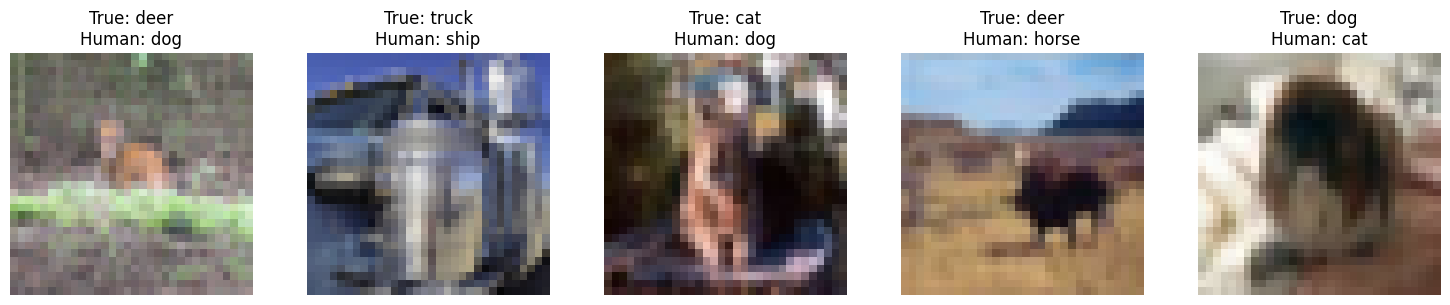

In [119]:

counts = np.load("data/cifar-10h/cifar10h-counts.npy")
# Human majority label for each image
human_labels = np.argmax(counts, axis=1)

# -----------------------------------
# Load CIFAR10 test labels
# -----------------------------------
testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True
)

true_labels = np.array(testset.targets)

# -----------------------------------
# Find mismatch image indices
# -----------------------------------
mismatch_indices = np.where(human_labels != true_labels)[0].tolist()

# -----------------------------------
# Results
# -----------------------------------
print("Number of mismatches:")
print(len(mismatch_indices))

print("\nMismatch indices:")
print(mismatch_indices)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# -----------------------------------
# Show 5 mismatch images
# -----------------------------------
plt.figure(figsize=(15, 3))

for i in range(5):

    idx = mismatch_indices[i]

    image, true_label = testset[idx]

    human_label = human_labels[idx]

    plt.subplot(1, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Human: {class_names[human_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [120]:
model_predictions = []

# Get the clean test transform we know works perfectly
_, test_transform = _build_transforms(rank_1_config)

with torch.no_grad():
    for idx in mismatch_indices:
        # 1. Grab the raw image
        image, _ = testset[idx]

        # 2. Convert PIL Image to PyTorch Tensor using test_transform
        image_tensor = test_transform(image)

        # 3. Add batch dimension and move to device safely
        image_tensor = image_tensor.unsqueeze(0).to(device)

        # 4. Forward pass
        outputs = model(image_tensor)

        # =====================================================================
        # PART D: Extract the highest probability class from the model prediction
        # =====================================================================
        pred_class = outputs.argmax(dim=1).item()
        model_predictions.append(pred_class)

# Convert predictions to a standard array for explicit checking
model_predictions = np.array(model_predictions)
print("\nHighest probability classes predicted by the model for the 79 images:")
print(model_predictions)


# =====================================================================
# PART D (Continued): Compare to true labels & calculate accuracy
# =====================================================================
correct_vs_true = 0
for i, idx in enumerate(mismatch_indices):
    if model_predictions[i] == true_labels[idx]:
        correct_vs_true += 1

print("\n==================================================")
print("             PART D FINAL EVALUATION             ")
print("==================================================")
print(f"The model predicted {correct_vs_true} out of {len(mismatch_indices)} images correctly when compared to TRUE labels.")
print(f"Subset Accuracy: {(correct_vs_true / len(mismatch_indices)) * 100:.2f}%")


# =====================================
# ADDITIONAL: AGREEMENT WITH HUMAN LABELS
# =====================================
correct_vs_humans = 0
for i, idx in enumerate(mismatch_indices):
    if model_predictions[i] == human_labels[idx]:
        correct_vs_humans += 1

print(f"\nThe model agreed with human labels on {correct_vs_humans} out of {len(mismatch_indices)} images.")
print(f"Subset Agreement: {(correct_vs_humans / len(mismatch_indices)) * 100:.2f}%")


Highest probability classes predicted by the model for the 79 images:
[8 5 5 7 3 5 7 3 4 1 7 3 4 4 8 6 7 4 3 3 1 8 7 4 9 2 3 7 1 9 5 4 3 8 6 3 4
 5 2 7 7 7 3 4 4 4 3 6 1 6 2 7 9 5 7 8 2 4 2 4 3 3 6 6 3 6 7 6 1 9 4 3 4 5
 4 7 4 7 4]

             PART D FINAL EVALUATION             
The model predicted 25 out of 79 images correctly when compared to TRUE labels.
Subset Accuracy: 31.65%

The model agreed with human labels on 27 out of 79 images.
Subset Agreement: 34.18%


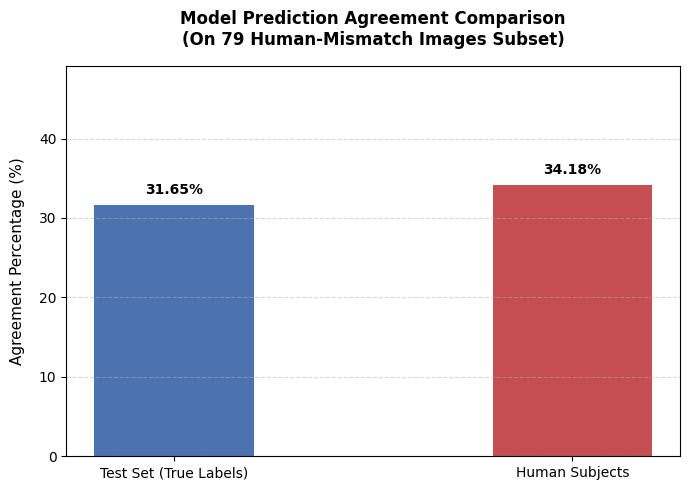

In [121]:
# 1. Calculate the agreement percentages from your existing counters
pct_true = (correct_vs_true / len(mismatch_indices)) * 100
pct_human = (correct_vs_humans / len(mismatch_indices)) * 100

# 2. Structure data into a list of tuples to allow automatic sorting
data = [
    ("Test Set (True Labels)", pct_true),
    ("Human Subjects", pct_human)
]

# Sort the data by percentage value (ascending order) as required
data_sorted = sorted(data, key=lambda x: x[1])

# Extract the sorted labels and values
labels = [item[0] for item in data_sorted]
percentages = [item[1] for item in data_sorted]

# 3. Create the plot using subplots (Avoiding plt.figure() as per guidelines)
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the bars with distinct professional colors
bar_colors = ['#4C72B0', '#C44E52']  # Muted blue and red
bars = ax.bar(labels, percentages, color=bar_colors, width=0.4)

# 4. Annotate values explicitly on top of each bar to ensure clear visibility
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 1,  # Position slightly above the top of the bar
        f"{height:.2f}%", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# 5. Professional formatting and label management
ax.set_ylabel('Agreement Percentage (%)', fontsize=11, labelpad=10)
ax.set_title('Model Prediction Agreement Comparison\n(On 79 Human-Mismatch Images Subset)', fontsize=12, pad=15, fontweight='bold')
ax.set_ylim(0, max(percentages) + 15)  # Add padding at the top so labels aren't cut off
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure non-overlapping elements and proper layout margins
plt.tight_layout()

# 6. Save the figure natively to the directory (Avoiding plt.show())
plt.savefig('model_agreement_comparison.png', dpi=300, bbox_inches='tight')

In [122]:
# 1. Load the requested CIFAR-10H probabilities file
cifar10h_probs = np.load("data/cifar-10h/cifar10h-probs.npy")
print(f"Loaded CIFAR-10H probabilities array with shape: {cifar10h_probs.shape}")

# Get the clean test transform we know works perfectly
_, test_transform = _build_transforms(rank_1_config)

# 2. Load full CIFAR10 test set WITH the transform attached (Fixes the crash!)
testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform  # <-- Added this line to fix the error
)

test_loader = DataLoader(
    testset, 
    batch_size=128, 
    shuffle=False, 
    num_workers=2
)

# ---------------------------------------------------------------------
# PART A: Predict on entire test set & extract true label SoftMax values
# ---------------------------------------------------------------------
model.eval()
model_true_class_probs = []

print("\nRunning model inference over the entire 10,000 image test set...")

with torch.no_grad():
    for images, targets in test_loader:
        # Move images and targets to device safely
        images = images.to(device)
        
        # Forward Pass to get raw outputs (logits)
        logits = model(images)
        
        # Apply Softmax to turn logits into real probabilities (0.0 to 1.0)
        probabilities = F.softmax(logits, dim=1)
        
        # Extract the probability corresponding to the true target label
        batch_indices = torch.arange(targets.size(0))
        true_label_probabilities = probabilities[batch_indices, targets]
        
        # Gather back to CPU list
        model_true_class_probs.extend(true_label_probabilities.cpu().tolist())

# Convert the final accumulation to a standard NumPy array
model_true_class_probs = np.array(model_true_class_probs)

# Verify Requirements met
print(f"Total extracted probabilities list size: {len(model_true_class_probs)}")
print("\nFirst 5 values showing model's confidence in the TRUE label:")
print(model_true_class_probs[:5])

human_true_class_probs = cifar10h_probs[np.arange(10000), true_labels]
print("\nFirst 5 values showing human subjects' confidence in the TRUE label:")
print(human_true_class_probs[:5])

Loaded CIFAR-10H probabilities array with shape: (10000, 10)

Running model inference over the entire 10,000 image test set...
Total extracted probabilities list size: 10000

First 5 values showing model's confidence in the TRUE label:
[0.81898397 0.74720985 0.70634389 0.66426182 0.84861583]

First 5 values showing human subjects' confidence in the TRUE label:
[0.94117647 0.98039216 1.         0.74509804 0.98039216]


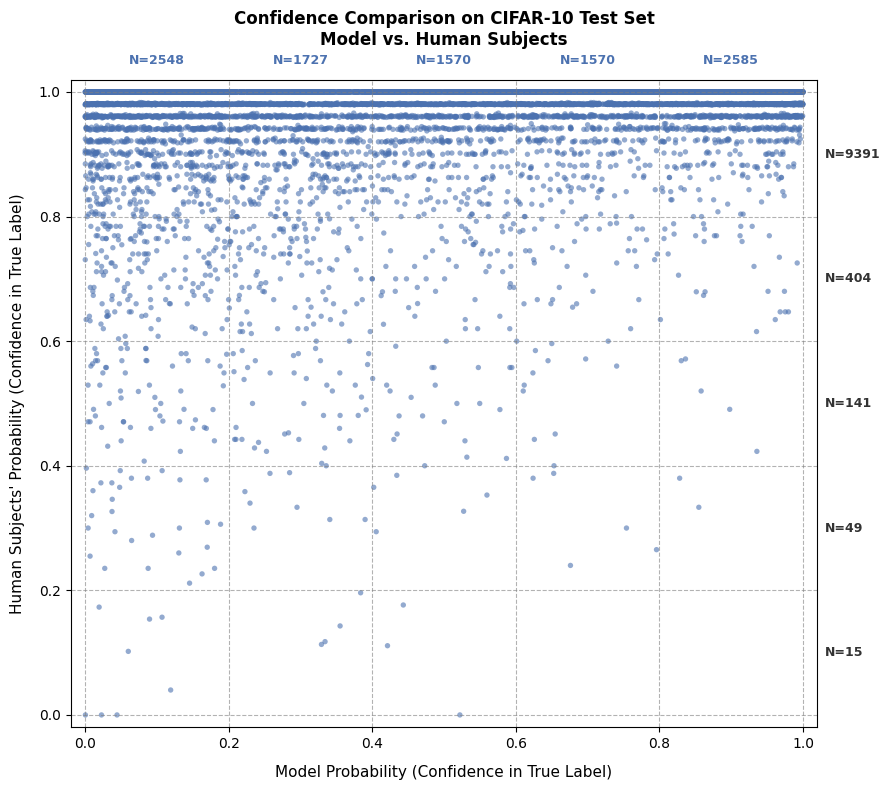

In [123]:
intervals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
grid_counts = np.zeros((5, 5), dtype=int)

for i in range(5):
    for j in range(5):
        x_min, x_max = intervals[i], intervals[i+1]
        y_min, y_max = intervals[j], intervals[j+1]
        
        x_cond = (model_true_class_probs >= x_min) & (model_true_class_probs <= x_max if i == 4 else model_true_class_probs < x_max)
        y_cond = (human_true_class_probs >= y_min) & (human_true_class_probs <= y_max if j == 4 else human_true_class_probs < y_max)
        
        grid_counts[j, i] = np.sum(x_cond & y_cond)

# Summarize totals per 20% range for both axes
model_totals = np.sum(grid_counts, axis=0)  # [0-20%, 20-40%, 40-60%, 60-80%, 80-100%]
human_totals = np.sum(grid_counts, axis=1)  # [0-20%, 20-40%, 40-60%, 60-80%, 80-100%]

# ---------------------------------------------------------------------
# 4. PLOT SCATTER GRAPH WITH MARGIN TOTALS
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

# Plot scatters with significantly increased visibility (alpha=0.6)
ax.scatter(
    model_true_class_probs, 
    human_true_class_probs, 
    alpha=0.6, 
    color='#4C72B0', 
    edgecolors='none', 
    s=15
)

# Labels & Title setup (clean title without artificial padding)
ax.set_xlabel('Model Probability (Confidence in True Label)', fontsize=11, labelpad=10)
ax.set_ylabel("Human Subjects' Probability (Confidence in True Label)", fontsize=11, labelpad=10)
ax.set_title('Confidence Comparison on CIFAR-10 Test Set\nModel vs. Human Subjects', fontsize=12, pad=25, fontweight='bold')

# --- Inject Marginal Numbers Exactly Fitting Their Grid Ranges ---

# 1. Plot Model Totals above the top X-axis (centered over each 20% column block)
for i in range(5):
    column_center = (intervals[i] + intervals[i+1]) / 2.0
    ax.text(
        column_center, 1.02, 
        f"N={model_totals[i]}", 
        transform=ax.get_xaxis_transform(), 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        color='#4C72B0', 
        fontweight='bold'
    )

# 2. Plot Human Totals aside the right Y-axis (centered beside each 20% row block)
for j in range(5):
    row_center = (intervals[j] + intervals[j+1]) / 2.0
    ax.text(
        1.01, row_center, 
        f"N={human_totals[j]}", 
        transform=ax.get_yaxis_transform(), 
        ha='left', 
        va='center', 
        fontsize=9, 
        color='#333333', 
        fontweight='bold'
    )

# Axis Configuration
ax.set_xticks(intervals)
ax.set_yticks(intervals)
ax.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('model_vs_human_probabilities.png', dpi=300, bbox_inches='tight')

BONUS


In [124]:
# Load dataset
raw_df = pd.read_csv("data/cifar-10h/cifar10h-raw/cifar10h-raw.csv")

# Filter out attention check trials
clean_df = raw_df[raw_df['is_attn_check'] == 0]

# Compute average reaction time per test image
avg_rt_per_image = clean_df.groupby('cifar10_test_test_idx')['reaction_time'].mean()

print(f"Computed average reaction times for {len(avg_rt_per_image)} unique images.")
print(avg_rt_per_image.head())

Computed average reaction times for 10000 unique images.
cifar10_test_test_idx
0    2004.941176
1    1571.076923
2    1656.865385
3    3261.745098
4    1651.039216
Name: reaction_time, dtype: float64


In [125]:
# 1. Align the model probabilities to match the aggregated reaction time indices
# This ensures every image ID maps to its correct model probability value
aligned_image_indices = avg_rt_per_image.index.to_numpy()
aligned_model_probs = model_true_class_probs[aligned_image_indices]
aligned_reaction_times = avg_rt_per_image.to_numpy()

# 2. Compute Pearson (linear) and Spearman (rank-based) correlations
pearson_corr, pearson_p = stats.pearsonr(aligned_model_probs, aligned_reaction_times)
spearman_corr, spearman_p = stats.spearmanr(aligned_model_probs, aligned_reaction_times)

print(f"Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")

Pearson correlation:  -0.1070 (p-value: 7.0497e-27)
Spearman correlation: -0.2901 (p-value: 4.4040e-193)


/tmp/ipykernel_2236729/2501098423.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=binned_data, x='Confidence_Bin', y='Human_Reaction_Time', ax=ax, palette='Blues_r')
/tmp/ipykernel_2236729/2501098423.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


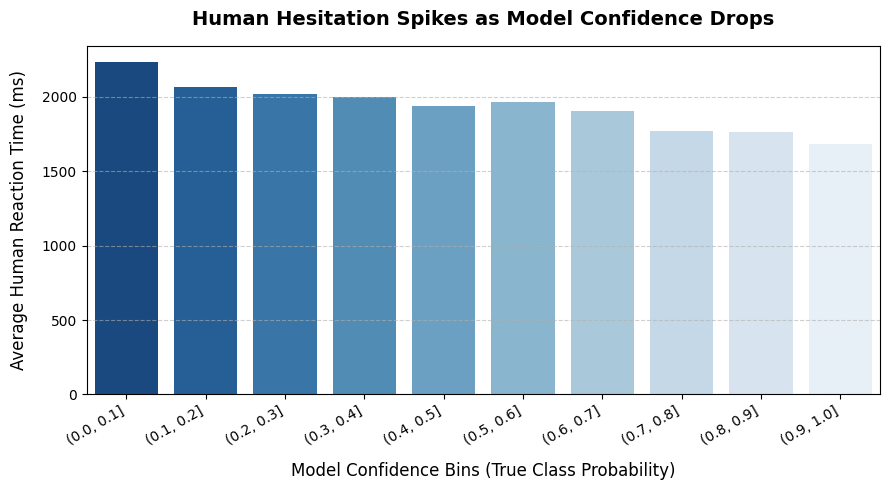

In [126]:
# 1. Create a clean DataFrame for plotting
plot_df = pd.DataFrame({
    'Model_Confidence': aligned_model_probs,
    'Human_Reaction_Time': aligned_reaction_times
})

# 2. Divide model probabilities into 10 equal intervals from 0.0 to 1.0
plot_df['Confidence_Bin'] = pd.cut(plot_df['Model_Confidence'], bins=np.linspace(0, 1, 11))

# 3. Compute the average human reaction time for each bin
binned_data = plot_df.groupby('Confidence_Bin', observed=False)['Human_Reaction_Time'].mean().reset_index()

# 4. Create the plot using subplots
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=binned_data, x='Confidence_Bin', y='Human_Reaction_Time', ax=ax, palette='Blues_r')

# 5. Format labels neatly to ensure no truncation or overlapping
ax.set_title("Human Hesitation Spikes as Model Confidence Drops", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Model Confidence Bins (True Class Probability)", fontsize=12, labelpad=10)
ax.set_ylabel("Average Human Reaction Time (ms)", fontsize=12, labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("binned_reaction_time_vs_confidence.png", dpi=300)

# REVISION: Replaced plt.close() with plt.show() to force rendering in the notebook cells
plt.show()

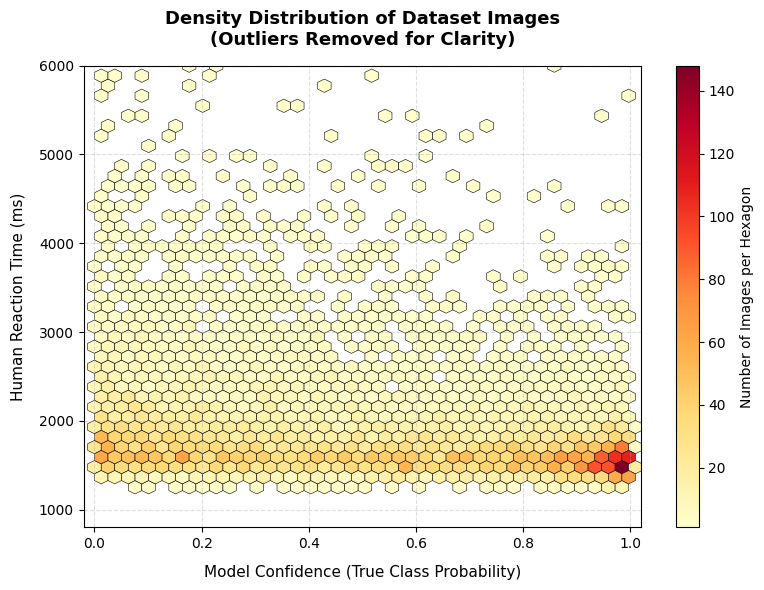

In [127]:
# Create a density hexbin plot
fig, ax = plt.subplots(figsize=(8, 6))

# REVISION: Added edgecolors and linewidths for clean, sharp hexagon borders
hb = ax.hexbin(
    aligned_model_probs, 
    aligned_reaction_times, 
    gridsize=40, 
    cmap='YlOrRd', 
    mincnt=1,
    extent=[0, 1.01, 800, 6000],  # [xmin, xmax, ymin, ymax]
    edgecolors='black',           # Fine black outline
    linewidths=0.4                # Thin line weight for clarity
)

# Add colorbar labeled for image count per region
fig.colorbar(hb, ax=ax, label='Number of Images per Hexagon')

# Match the axis limits to the calculated extent
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(800, 6000) 

# Axis and Labels Configuration
ax.set_title("Density Distribution of Dataset Images\n(Outliers Removed for Clarity)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Model Confidence (True Class Probability)", fontsize=11, labelpad=10)
ax.set_ylabel("Human Reaction Time (ms)", fontsize=11, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("density_hexbin_fixed_scale.png", dpi=300, bbox_inches='tight')
plt.show()